In [6]:
import pandas as pd
import matplotlib.pyplot as plt 
import gzip
import csv
import seaborn as sns
import plotly.express as px

In [20]:
trashwheel = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-03-05/trashwheel.csv')

In [4]:
trashwheel

,ID,Name,Dumpster,Month,Year,Date,Weight,Volume,PlasticBottles,Polystyrene,CigaretteButts,GlassBottles,PlasticBags,Wrappers,SportsBalls,HomesPowered
0,mister,Mister Trash Wheel,1,May,2014,5/16/2014,4.31,18,1450.0,1820.0,126000.0,72.0,584.0,1162.0,7.0,0
1,mister,Mister Trash Wheel,2,May,2014,5/16/2014,2.74,13,1120.0,1030.0,91000.0,42.0,496.0,874.0,5.0,0
2,mister,Mister Trash Wheel,3,May,2014,5/16/2014,3.45,15,2450.0,3100.0,105000.0,50.0,1080.0,2032.0,6.0,0
3,mister,Mister Trash Wheel,4,May,2014,5/17/2014,3.10,15,2380.0,2730.0,100000.0,52.0,896.0,1971.0,6.0,0
4,mister,Mister Trash Wheel,5,May,2014,5/17/2014,4.06,18,980.0,870.0,120000.0,72.0,368.0,753.0,7.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,gwynnda,Gwynnda Trash Wheel,215,December,2023,12/27/23,3.96,15,500.0,40.0,1000.0,NaN,40.0,750.0,NaN,66
989,gwynnda,Gwynnda Trash Wheel,216,December,2023,12/27/23,3.38,15,1200.0,90.0,1200.0,NaN,60.0,1000.0,NaN,56
990,gwynnda,Gwynnda Trash Wheel,217,December,2023,12/28/23,4.02,15,180.0,24.0,360.0,NaN,40.0,400.0,NaN,67
991,gwynnda,Gwynnda Trash Wheel,218,December,2023,12/29/23,3.49,15,0.0,0.0,0.0,NaN,0.0,0.0,NaN,58


In [5]:
trashwheel.isnull().sum()

ID                  0
Name                0
Dumpster            0
Month               0
Year                0
Date                0
Weight              0
Volume              0
PlasticBottles      1
Polystyrene         1
CigaretteButts      1
GlassBottles      251
PlasticBags         1
Wrappers          144
SportsBalls       364
HomesPowered        0
dtype: int64

In [12]:
trashwheel.groupby('Name').size()

Name
Captain Trash Wheel       30
Gwynnda Trash Wheel      220
Mister Trash Wheel       629
Professor Trash Wheel    114
dtype: int64

In [21]:
trashwheel.dtypes

ID                 object
Name               object
Dumpster            int64
Month              object
Year                int64
Date               object
Weight            float64
Volume              int64
PlasticBottles    float64
Polystyrene       float64
CigaretteButts    float64
GlassBottles      float64
PlasticBags       float64
Wrappers          float64
SportsBalls       float64
HomesPowered        int64
dtype: object

In [24]:
# There's better data for just Mister Trash Wheel
trashwheel_refined = trashwheel[trashwheel['Name'] == 'Mister Trash Wheel']
trashwheel_refined = trashwheel_refined[trashwheel_refined['Year'] == 2023]
# trashwheel_refined = trashwheel_refined[trashwheel_refined['Month'] == 'December']

In [25]:
trashwheel_refined

,ID,Name,Dumpster,Month,Year,Date,Weight,Volume,PlasticBottles,Polystyrene,CigaretteButts,GlassBottles,PlasticBags,Wrappers,SportsBalls,HomesPowered
567,mister,Mister Trash Wheel,568,January,2023,1/27/2023,3.23,15,1700.0,210.0,2900.0,15.0,180.0,1500.0,10.0,54
568,mister,Mister Trash Wheel,569,February,2023,2/20/2023,3.03,15,2400.0,300.0,3300.0,21.0,210.0,1100.0,21.0,51
569,mister,Mister Trash Wheel,570,February,2023,2/20/2023,3.53,15,3600.0,280.0,4200.0,24.0,240.0,2200.0,30.0,59
570,mister,Mister Trash Wheel,571,March,2023,3/6/2023,3.14,15,2700.0,180.0,3200.0,18.0,270.0,1700.0,20.0,52
571,mister,Mister Trash Wheel,572,March,2023,3/29/2023,3.41,15,2900.0,200.0,3000.0,20.0,200.0,1400.0,14.0,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,mister,Mister Trash Wheel,625,December,2023,12/12/2023,3.73,15,2100.0,190.0,3000.0,22.0,190.0,1200.0,20.0,62
625,mister,Mister Trash Wheel,626,December,2023,12/20/2023,3.01,15,1400.0,120.0,2900.0,12.0,220.0,980.0,32.0,50
626,mister,Mister Trash Wheel,627,December,2023,12/20/2023,2.34,15,880.0,75.0,2600.0,8.0,140.0,1400.0,10.0,39
627,mister,Mister Trash Wheel,628,December,2023,12/23/2023,2.88,15,2000.0,140.0,3200.0,18.0,200.0,1900.0,22.0,48


In [27]:
avg_plastic = int(trashwheel_refined['PlasticBottles'].mean())
avg_glass = int(trashwheel_refined['GlassBottles'].mean())
avg_polyesterne = int(trashwheel_refined['Polystyrene'].mean())
avg_cigarette = int(trashwheel_refined['CigaretteButts'].mean())
avg_bags = int(trashwheel_refined['PlasticBags'].mean())
avg_sports = int(trashwheel_refined['SportsBalls'].mean())
avg_wrappers = int(trashwheel_refined['Wrappers'].mean())

In [104]:
trash_breakdown = {
    'Plastic Bottles': avg_plastic,
    'Glass Bottles': avg_glass,
    'Plastic Bags': avg_bags,
    'Polyesterene Items': avg_polyesterne,
    'Wrappers': avg_wrappers,
    'Sports Balls': avg_sports,
    'Cigarette Butts': avg_cigarette
}

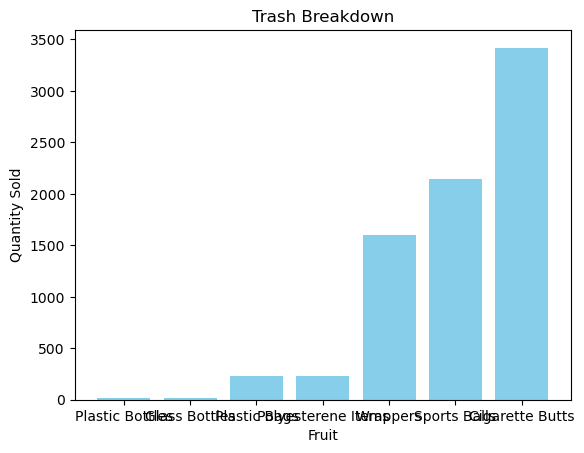

In [ ]:
labels = list(trash_breakdown.keys())
values = sorted(list(trash_breakdown.values()))

In [129]:
fig=px.bar(
    x=labels,
    y=values,
    title='Average No.of items collected by Mister Trash Wheel in 2023',
    color_discrete_sequence=['skyblue']
)

fig.update_traces(
    hovertemplate=(
        'Average no.of %{x} collected: %{y:.2f}'
    )
)

fig.update_layout(
    autosize=False,
    xaxis_title='Item Type',
    yaxis_title='Average No.of Items',
    margin=dict(b=130),
    height=700,
    width = 700,
    plot_bgcolor='white',
    annotations=[
        dict(
            text="Mr. Trash Wheel is a semi-autonomous trash interceptor place at the end of a river, stream or other outfall",
            xref="paper", yref="paper",
            x=-0.09, y=1.10,
            showarrow=False,
            font=dict(size=12),
            font_color='grey'
        ),
        dict(
            text="Source: The Baltimore Healthy Harbor Initiative (Found through Tidy Tuesday datasets) ",
            xref="paper", yref="paper",
            x=0.5, y=-0.25,
            showarrow=False,
            font=dict(size=10),
            font_color='grey'
        ),
    ],
    images=[
        dict(
            source="https://media.istockphoto.com/id/844061970/vector/water-bottle-flat-icon.jpg?s=612x612&w=0&k=20&c=lowO7ydHylqab38fSlr7u1QpK6PZyfPK9ayOyZUWV3E=",
            xref="paper", yref="paper",
            x=0.08, y=0.06,
            sizex=0.08, sizey=0.08,
            xanchor="center", yanchor="middle",
            opacity=0.8,
            layer="above"
        ),
        dict(
            source="https://png.pngtree.com/png-clipart/20230930/original/pngtree-glass-bottle-clipart-png-image_13023575.png",
            xref="paper", yref="paper",
            x=0.21, y=0.06,
            sizex=0.08, sizey=0.08,
            xanchor="center", yanchor="middle",
            opacity=0.8,
            layer="above"
        ),
        dict(
            source="https://static.vecteezy.com/system/resources/previews/024/085/222/non_2x/blue-plastic-bag-illustration-isolated-on-square-white-background-simple-flat-drawing-with-outlined-cartoon-art-style-free-vector.jpg",
            xref="paper", yref="paper",
            x=0.36, y=0.13,
            sizex=0.1, sizey=0.1,
            xanchor="center", yanchor="middle",
            opacity=0.8,
            layer="above"
        ),
        dict(
            source="https://thumbs.dreamstime.com/b/polyester-fabric-cloth-color-icon-vector-illustration-polyester-fabric-cloth-color-icon-vector-polyester-fabric-cloth-sign-270256578.jpg",
            xref="paper", yref="paper",
            x=0.50, y=0.13,
            sizex=0.1, sizey=0.1,
            xanchor="center", yanchor="middle",
            opacity=0.8,
            layer="above"
        ),
        dict(
            source="https://t4.ftcdn.net/jpg/01/88/55/59/360_F_188555906_Ff7lLYtvjtt2Owvm0kPqY9NpHJJKTqlZ.jpg",
            xref="paper", yref="paper",
            x=0.64, y=0.51,
            sizex=0.1, sizey=0.1,
            xanchor="center", yanchor="middle",
            opacity=0.8,
            layer="above"
        ),
        dict(
            source="https://static.vecteezy.com/system/resources/thumbnails/001/226/227/small/sport-balls-collection.jpg",
            xref="paper", yref="paper",
            x=0.77, y=0.68,
            sizex=0.1, sizey=0.1,
            xanchor="center", yanchor="middle",
            opacity=0.8,
            layer="above"
        ),
        dict(
            source="https://media.istockphoto.com/id/1288942984/vector/cigarette-butt-set-of-trash-dirt-and-garbage.jpg?s=612x612&w=0&k=20&c=qGmFCkOZX7lJ0IWxUHG7z1Aof5DDyt0mLtV-e9pPrtg=",
            xref="paper", yref="paper",
            x=0.93, y=1.0,
            sizex=0.1, sizey=0.1,
            xanchor="center", yanchor="middle",
            opacity=0.8,
            layer="above"
        )
    ]
)

fig.show()

In [130]:
fig.write_html("30DayChart-10.html")
fig.write_image("30DayChart-10.png")